### **Лаба 1, краткая информация, что сделать, кто участвовал, какие части делал. вводную инфу добавить в общем**

### Include necessary frameworks

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf # only for loading dataset

### Loading and preprocess data

In [2]:
# Loading from Tensorflow.Keras
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train.shape, # 60 thousand of handwritten digits in size 28 x 28 pixels (3D-array), values from 0 to 255
      y_train.shape) # 60 thousand of correct digits (1D-array), target variables

(60000, 28, 28) (60000,)


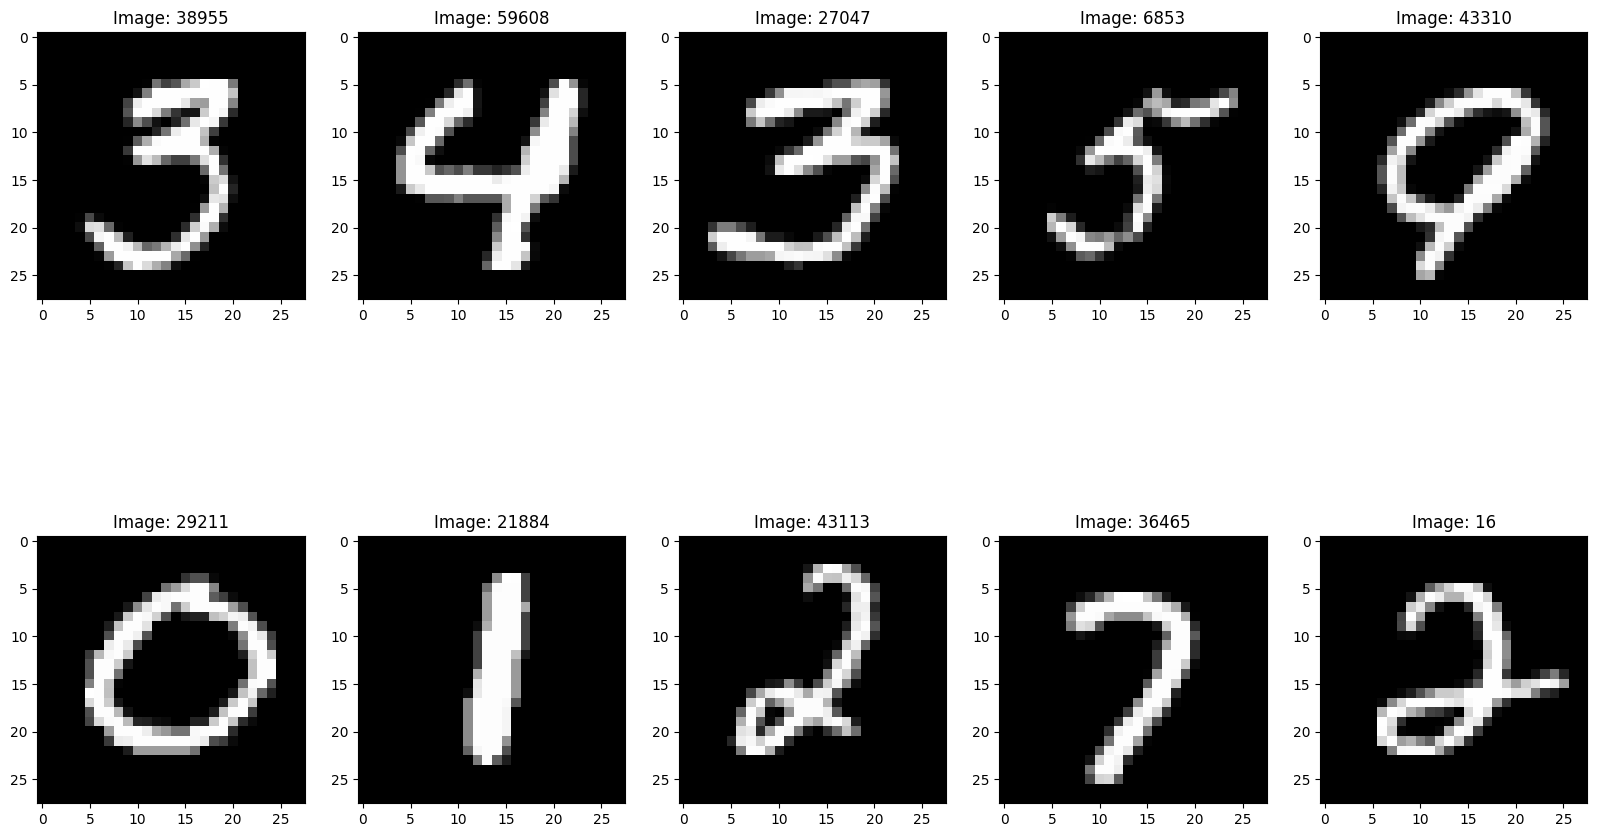

In [4]:
x_train, x_test = x_train / 255, x_test / 255 # normalization (from 0 to 1)

# vizualization of the dataset
fig, ax = plt.subplots(2, 5, figsize=(20,12))
rand_samples = np.random.randint(0, len(x_train), (2,5))
for i in range(2):
  for j in range(5):
    ax[i][j].imshow(x_train[rand_samples[i][j]], cmap="grey")
    ax[i][j].set_title(f"Image: {rand_samples[i][j]}")
    plt.show

In [5]:
# Flattening images (60000 * 28 * 28 -> 60000 * 784)
x_train_flat = x_train.reshape(len(x_train), (28*28)) # 60000 * 784
x_test_flat = x_test.reshape(len(x_test), (28*28)) # 10000 * 784

x_train_flat[0][150:250] # now image is presented in vector with size (1 * 784)

array([0.        , 0.        , 0.01176471, 0.07058824, 0.07058824,
       0.07058824, 0.49411765, 0.53333333, 0.68627451, 0.10196078,
       0.65098039, 1.        , 0.96862745, 0.49803922, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.11764706, 0.14117647, 0.36862745, 0.60392157,
       0.66666667, 0.99215686, 0.99215686, 0.99215686, 0.99215686,
       0.99215686, 0.88235294, 0.6745098 , 0.99215686, 0.94901961,
       0.76470588, 0.25098039, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.19215686, 0.93333333,
       0.99215686, 0.99215686, 0.99215686, 0.99215686, 0.99215686,
       0.99215686, 0.99215686, 0.99215686, 0.98431373, 0.36470588,
       0.32156863, 0.32156863, 0.21960784, 0.15294118, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [6]:
# Encoding traget variable for further convenient use
def onehot(np_array):
  """One-hot encoding digits from y_train to 2D-array (60000, 10) with "1" in position [digit]"""
  res = np.zeros((len(np_array), len(np.unique(np_array))))
  for i in range(len(np_array)):
    res[i][np_array[i]] = 1
  return res

y_train_onehot = onehot(y_train) # 60000 * 10
y_test_onehot = onehot(y_test) # 10000 * 10

y_train_onehot[0] # first digit is 5. It is represented as 1 on 5th index of first row

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### Neural Network classes definition


In [58]:
class Layer():
  """Base abstract class"""

  def forward_prop():
    pass

  def backward_prop():
    pass

class LinearLayer(Layer):
  """Derived class with weights and biases to calculate values through it"""

  def __init__(self, input_size, output_size):
    self.weights = np.random.rand(input_size, output_size)
    self.bias = np.zeros((1, output_size))

  def forward_prop(self, input_vals):
    return input_vals @ self.weights + self.bias

  def backward_prop():
    # need an implementation
    pass

class ReLU(Layer):
  """Class of activation function after hidden neurons that returns 0 or positive value"""

  def forward_prop(self, input_vals):
    self.input = input_vals
    self.output = np.maximum(0, input_vals)
    return self.output

  def backward_prop():
    # need an implementation
    pass

class Softmax(Layer):
  """Class of final activation function that converts logits into probalities"""

  def forward_prop(self, input_vals):
    exp_vals = np.exp(input_vals - np.max(input_vals))
    self.output = exp_vals / np.sum(exp_vals)
    return self.output

  def backward_prop():
    # need an implementation
    pass

class CrossEntropy(Layer):
  """Class of loss-function"""

  # need an implementation
  pass

class GradientDescend(Layer):
  """Class of optimization-function"""

  # need an implementation
  pass

class NeuralNetwork():
  """Sequential class that holds and manages layers inside Neural Network"""

  def __init__(self):
    self.layers = []
    self.loss_func = None # MSE / Cross Entropy

  def add_layer(self, layer):
    self.layers.append(layer)

  def forward_prop(self, input_vals):
    output = input_vals
    for layer in self.layers:
      output = layer.forward_prop(output)
    return output

  def backward_prop():
    # need an implementation
    pass

  def parameters():
    # need an implementation
    pass

  def gradients():
    # need an implementation
    pass

### Training and evaluating the model

In [61]:
# Initializing layers
layer1 = LinearLayer(784, 128)
layer1_relu = ReLU()
layer2 = LinearLayer(128, 10)
layer_softmax = Softmax()

# Initializing the Network
MyNN = NeuralNetwork()
MyNN.add_layer(layer1)
MyNN.add_layer(layer1_relu)
MyNN.add_layer(layer2)
MyNN.add_layer(layer_softmax)

# Forward propagation of unlearned model
for i in range(10):
  output = MyNN.forward_prop(x_train_flat[i])
  print(f"Array of probabilities for {i} image: {np.round(output, decimals=2)}")

Array of probabilities for 0 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 1 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 2 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 3 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 4 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 5 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 6 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 7 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 8 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Array of probabilities for 9 image: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
